# Carotid Artery Atherosclerosis Dataset

Notebook này thực hiện hai phần:
1. Khám phá dữ liệu bằng thống kê bảng và preview ảnh.
2. Mô hình đa mô thức (ảnh siêu âm + tabular clinical data) với các kỹ thuật cải tiến.

In [1]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [2]:
dataset_root = Path.cwd()
csv_path = dataset_root / 'carotid_clinical_dataset_300cases.csv'
image_dir = dataset_root / 'CAROTID_IMAGES'

df = pd.read_csv(csv_path)
df.head()

,Patient_ID,Age,Sex,Lp(a)_mg_dL,ApoB_mg_dL,LDL_C_mg_dL,Triglyceride_mg_dL,Total_Cholesterol_mg_dL,Non_HDL_mg_dL,IMT_mm,Plaque_present,Plaque_echogenicity,Baseline_Risk_Score,Baseline_Risk_Category,Associated_Images
0,P001,59,Male,10.0,97.7,157.6,123.4,195.3,150.0,0.710,0,NaN,0.49,Low,P001_IMT.png
1,P002,53,Male,37.6,128.0,159.7,152.8,185.8,139.4,0.698,0,NaN,0.11,Low,P002_IMT.png
2,P003,61,Female,18.2,140.4,146.0,86.0,187.1,135.2,0.733,1,Low,0.14,Low,"P003_IMT.png,P003_CCA_L1.png,P003_CCA_L2.png,P..."
3,P004,70,Female,38.2,101.5,101.4,71.1,140.7,102.2,0.879,1,Intermediate,0.00,Low,"P004_IMT.png,P004_CCA_L1.png,P004_CCA_L2.png,P..."
4,P005,52,Female,17.2,99.2,170.8,70.0,186.8,156.9,0.637,0,NaN,0.08,Low,P005_IMT.png


In [3]:
summary = {
    'patients': len(df),
    'plaque_present': df['Plaque_present'].value_counts().to_dict(),
    'echogenicity': df['Plaque_echogenicity'].value_counts().to_dict(),
    'risk_category': df['Baseline_Risk_Category'].value_counts().to_dict(),
    'image_group': df['Associated_Images'].fillna('').apply(lambda x: len([p for p in str(x).split(',') if p.strip()])).value_counts().to_dict(),
}
summary

{'patients': 300,
 'plaque_present': {0: 205, 1: 95},
 'echogenicity': {'Intermediate': 40, 'Low': 28, 'High': 27},
 'risk_category': {'Low': 293, 'Moderate': 7},
 'image_group': {1: 205, 5: 95}}

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_32448\3847097968.py:13: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  df[['Age', 'IMT_mm', 'Lp(a)_mg_dL', 'ApoB_mg_dL']].hist(ax=axes[2], bins=15, color='#ff7f0e')


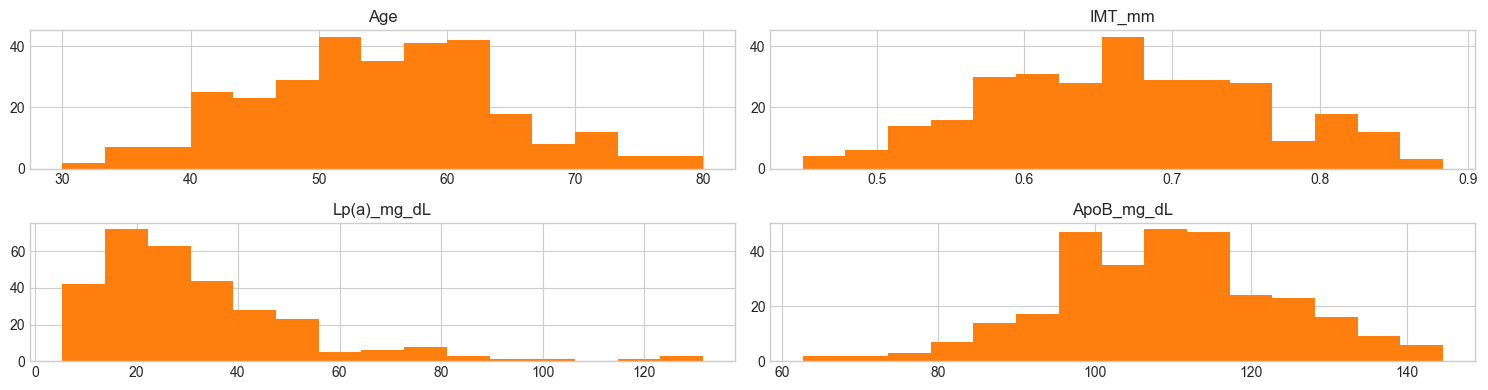

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Plaque_present'].map({0: 'Control', 1: 'Plaque'}).value_counts().plot(kind='bar', ax=axes[0], color=['#1f77b4', '#d62728'])
axes[0].set_title('Plaque label distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')

df['Baseline_Risk_Category'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#2ca02c')
axes[1].set_title('Baseline risk category')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')

df[['Age', 'IMT_mm', 'Lp(a)_mg_dL', 'ApoB_mg_dL']].hist(ax=axes[2], bins=15, color='#ff7f0e')
axes[2].set_title('Selected clinical features')

plt.tight_layout()

In [5]:
def parse_images(value):
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split(',') if item.strip()]

df['image_list'] = df['Associated_Images'].apply(parse_images)
control_ids = df.loc[df['Plaque_present'] == 0, 'Patient_ID'].head(3).tolist()
plaque_ids = df.loc[df['Plaque_present'] == 1, 'Patient_ID'].head(3).tolist()
preview_ids = control_ids + plaque_ids
preview_ids

['P001', 'P002', 'P005', 'P003', 'P004', 'P011']

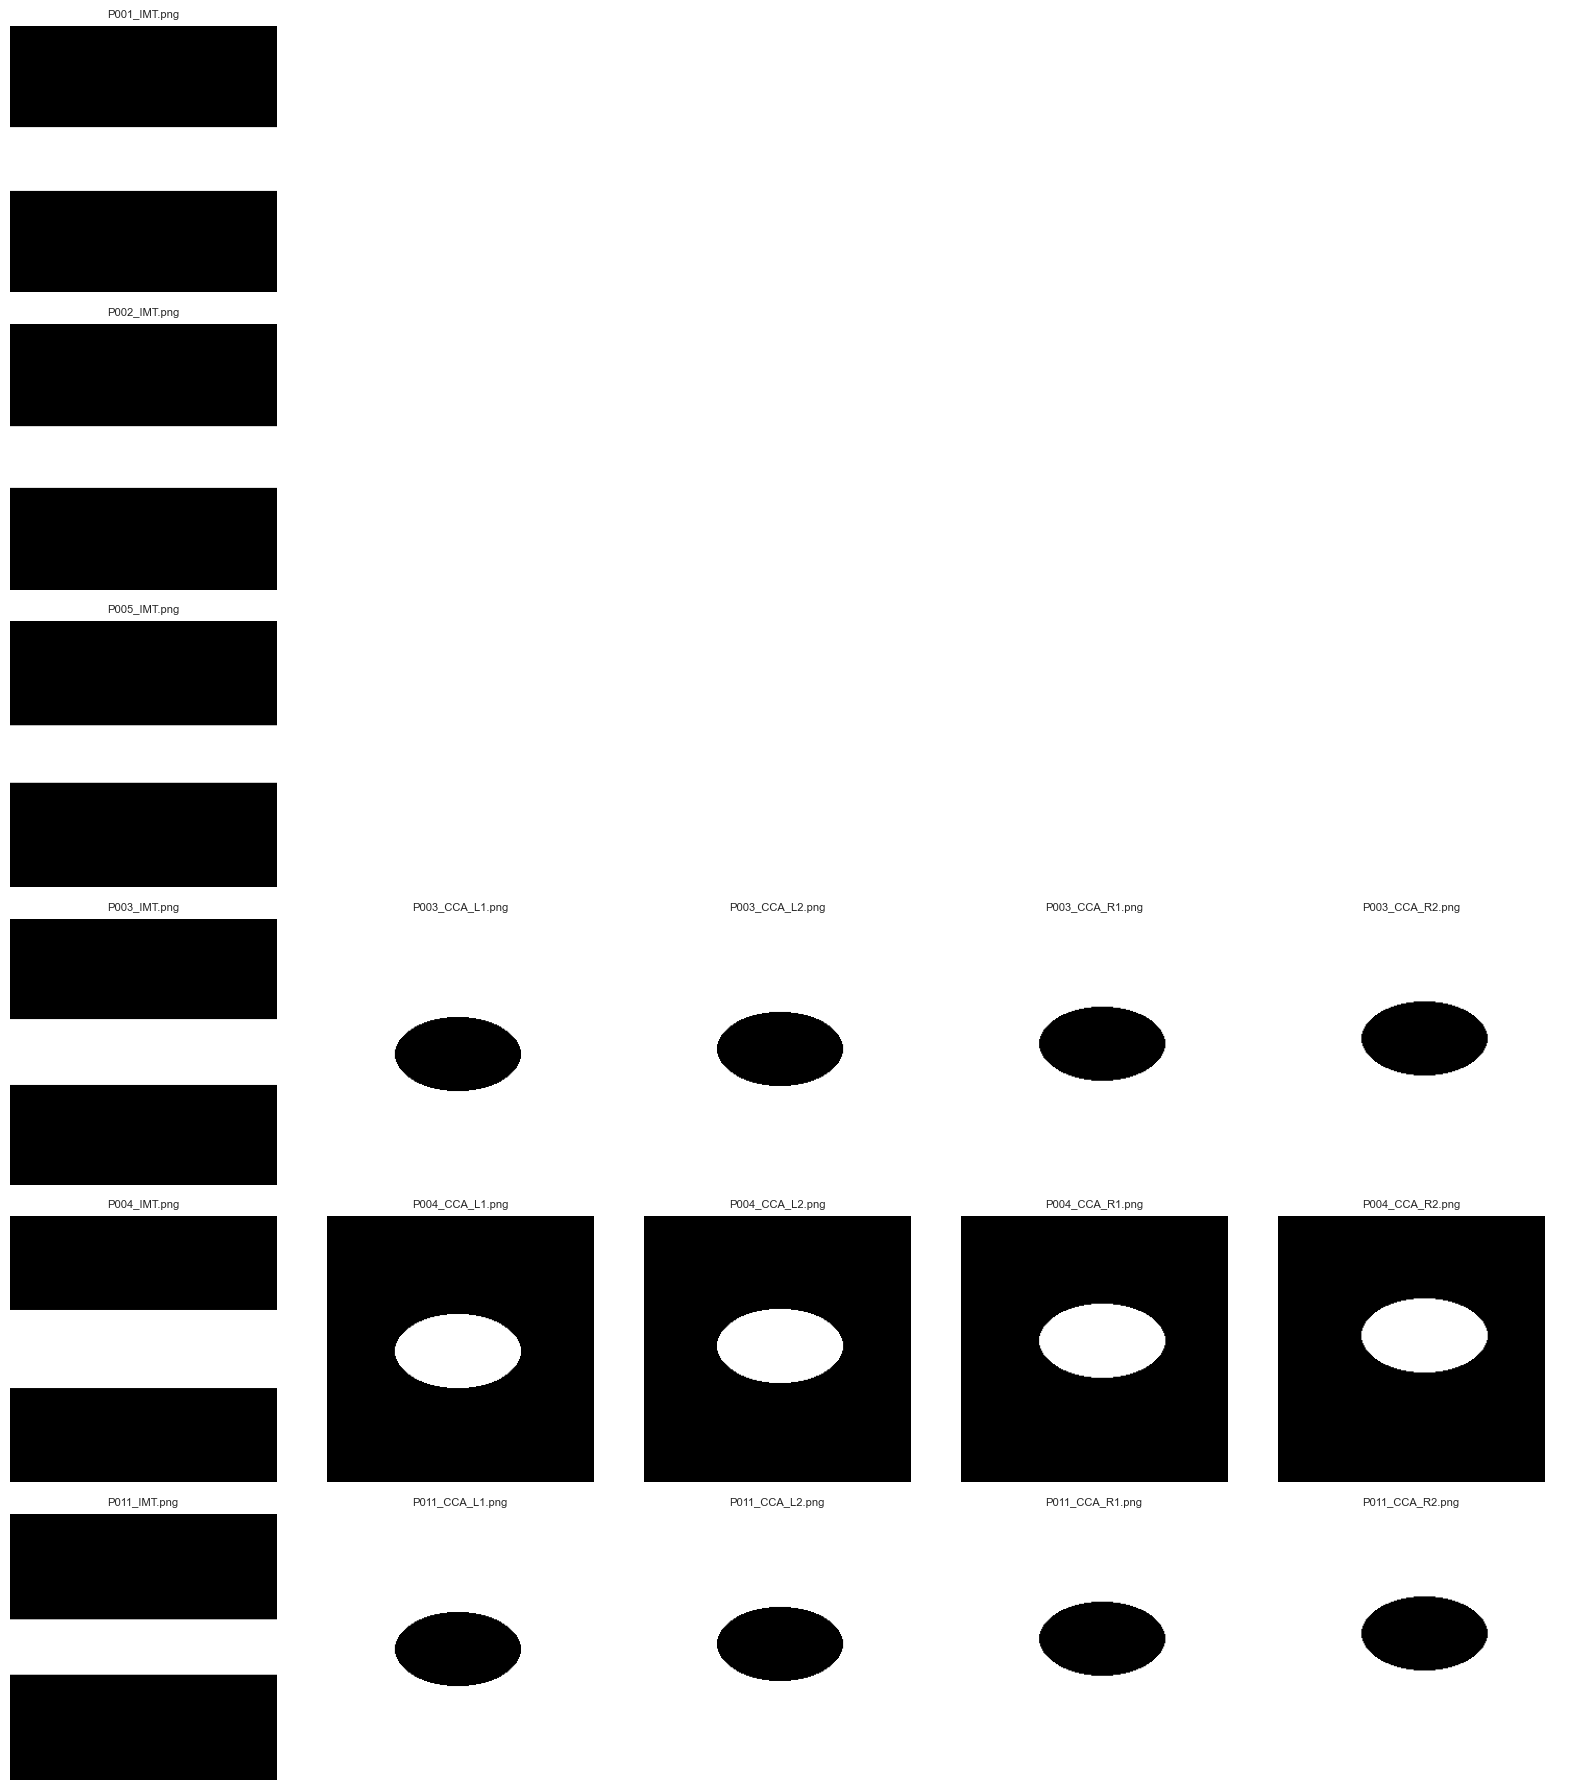

In [6]:
fig, axes = plt.subplots(len(preview_ids), 5, figsize=(16, 3 * len(preview_ids)))
axes = np.atleast_2d(axes)

for row_idx, patient_id in enumerate(preview_ids):
    record = df.loc[df['Patient_ID'] == patient_id].iloc[0]
    image_names = record['image_list']
    for col_idx in range(5):
        ax = axes[row_idx, col_idx]
        ax.axis('off')
        if col_idx < len(image_names):
            image_path = image_dir / image_names[col_idx]
            image = Image.open(image_path)
            ax.imshow(image, cmap='gray')
            ax.set_title(image_names[col_idx], fontsize=8)
        else:
            ax.set_title('')
    axes[row_idx, 0].set_ylabel(f"{patient_id}\nlabel={int(record['Plaque_present'])}", rotation=0, labelpad=40, va='center')

plt.tight_layout()

SCORE2/SCORE2-OP statistics:
count    300.0000
mean       0.2350
std        0.3341
min        0.0000
25%        0.0030
50%        0.0468
75%        0.3616
max        1.0000
Name: SCORE2, dtype: float64

Mean SCORE2 by Plaque_present:
Plaque_present
Control    0.1863
Plaque     0.3400
Name: SCORE2, dtype: float64


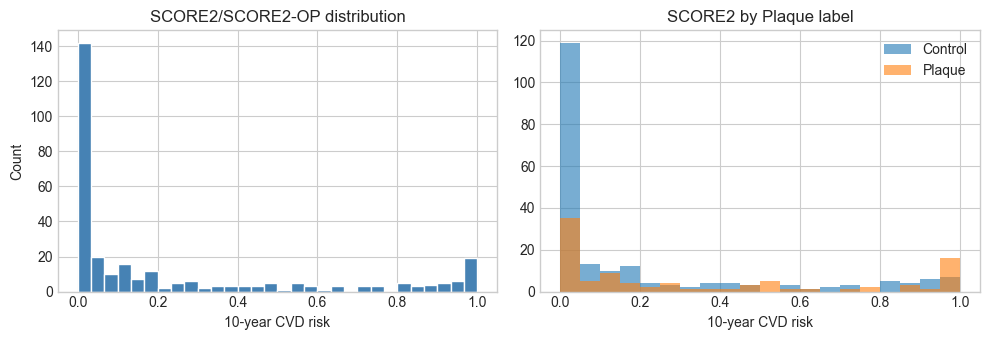

In [7]:
# SCORE2 / SCORE2-OP — ESC 10-year CVD risk score (low-risk region)
# Ref: SCORE2 working group. Eur Heart J. 2021;42:2439-2454
#      SCORE2-OP working group. Eur Heart J. 2022;43:2444-2456
#
# Giả định: SBP = 130 mmHg, không hút thuốc (không có trong dataset)
# SCORE2 áp dụng cho tuổi 40–69; SCORE2-OP cho tuổi ≥70 → ra 1 feature thống nhất

def compute_score2(age, sex_male, non_hdl_mg_dL, sbp=130, smoking=0):
    """10-year CVD event risk (0–1), low-risk European region."""
    nhdl = non_hdl_mg_dL * 0.02586          # mg/dL → mmol/L

    if age < 70:                             # SCORE2 (40–69 yr)
        if sex_male:
            alpha = -0.5699
            lp = (0.3742 * (age - 60)
                  + 0.6012 * smoking
                  + 0.2777 * (sbp - 120) / 20
                  + 0.1458 * (nhdl - 3.9)
                  + 0.0304 * (age - 60) * smoking
                  - 0.0010 * (age - 60) * (sbp - 120) / 20)
        else:
            alpha = -0.7577
            lp = (0.4648 * (age - 60)
                  + 0.7744 * smoking
                  + 0.3131 * (sbp - 120) / 20
                  + 0.1002 * (nhdl - 3.9)
                  + 0.0115 * (age - 60) * smoking
                  - 0.0018 * (age - 60) * (sbp - 120) / 20)
    else:                                    # SCORE2-OP (≥70 yr)
        if sex_male:
            alpha = -1.7600
            lp = (0.5674 * (age - 73)
                  + 0.5640 * smoking
                  + 0.1814 * (sbp - 150) / 20
                  + 0.0744 * (nhdl - 4.4)
                  - 0.0288 * (age - 73) * smoking)
        else:
            alpha = -1.8673
            lp = (0.5946 * (age - 73)
                  + 0.5748 * smoking
                  + 0.2456 * (sbp - 150) / 20
                  + 0.0611 * (nhdl - 4.4)
                  - 0.0220 * (age - 73) * smoking)

    return float(np.clip(1 - np.exp(-np.exp(alpha + lp)), 0.0, 1.0))


df['SCORE2'] = df.apply(
    lambda r: compute_score2(
        age=r['Age'],
        sex_male=1 if r['Sex'] == 'Male' else 0,
        non_hdl_mg_dL=r['Non_HDL_mg_dL'],
    ),
    axis=1,
)

print("SCORE2/SCORE2-OP statistics:")
print(df['SCORE2'].describe().round(4))
print("\nMean SCORE2 by Plaque_present:")
print(df.groupby('Plaque_present')['SCORE2'].mean().round(4).rename({0: 'Control', 1: 'Plaque'}))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df['SCORE2'].hist(bins=30, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('SCORE2/SCORE2-OP distribution')
axes[0].set_xlabel('10-year CVD risk')
axes[0].set_ylabel('Count')

for label, grp in df.groupby('Plaque_present'):
    axes[1].hist(grp['SCORE2'], bins=20, alpha=0.6,
                 label='Plaque' if label else 'Control')
axes[1].set_title('SCORE2 by Plaque label')
axes[1].set_xlabel('10-year CVD risk')
axes[1].legend()
plt.tight_layout()


## ⚠️ Kiểm tra tính toàn vẹn dữ liệu (Data Integrity Audit)

Kiểm tra rò rỉ dữ liệu (data leakage) trước khi huấn luyện. Phát hiện **rò rỉ nghiêm trọng qua số lượng ảnh**:

| Nguồn rò rỉ | Vấn đề | Xử lý |
|---|---|---|
| **Số lượng ảnh** | Control có đúng 1 ảnh, Plaque có đúng 5 ảnh → correlation với nhãn = **1.0** | Chỉ dùng ảnh `_IMT.png` (mọi bệnh nhân đều có) |
| Ảnh `CCA_L/R` | Chỉ tồn tại ở ca Plaque → sự hiện diện của ảnh chính là nhãn | Loại khỏi mô hình |
| `Plaque_echogenicity` | Chỉ có giá trị ở ca Plaque | Không dùng làm feature |
| `Baseline_Risk_Score` | Điểm nguy cơ tính sẵn, có thể chứa thông tin nhãn | Không dùng làm feature |

Nếu không sửa, model đạt accuracy ~100% **giả tạo** (chỉ học "5 ảnh có giống hệt nhau không"). Sau khi chỉ dùng ảnh IMT, hiệu năng thực tế phụ thuộc vào tín hiệu tabular (`IMT_mm`, `Age`).

In [8]:
# ─── Data leakage audit: số lượng ảnh vs nhãn ────────────────────────────────
def parse_images(value):
    if pd.isna(value):
        return []
    return [item.strip() for item in str(value).split(',') if item.strip()]

df['image_list_full'] = df['Associated_Images'].apply(parse_images)
df['n_images'] = df['image_list_full'].apply(len)

print("Số lượng ảnh × nhãn (crosstab):")
print(pd.crosstab(df['n_images'], df['Plaque_present'],
                  rownames=['n_images'], colnames=['Plaque']))
leak_corr = df['n_images'].corr(df['Plaque_present'])
print(f"\n⚠️  Correlation(n_images, Plaque_present) = {leak_corr:.4f}"
      f"  →  {'RÒ RỈ!' if abs(leak_corr) > 0.5 else 'ok'}")

# Xác nhận mọi bệnh nhân đều có ảnh IMT → dùng chung được cho cả 2 lớp
def imt_only(names):
    imt = [n for n in names if '_IMT' in n]
    return imt[:1] if imt else names[:1]

df['image_list'] = df['image_list_full'].apply(imt_only)
assert df['image_list'].apply(len).eq(1).all(), "Có bệnh nhân thiếu ảnh IMT!"
print(f"\n✅  Đã đổi sang chỉ dùng 1 ảnh IMT/bệnh nhân → n_images không còn rò rỉ.")

# Kiểm tra ảnh IMT có phân biệt được 2 lớp không (pixel stats)
def _imt_stat(name):
    a = np.asarray(Image.open(image_dir / name).convert('L'), dtype=np.float32)
    return a.mean(), a.std()

_stats = df.assign(_s=df['image_list'].apply(lambda L: _imt_stat(L[0])))
_stats['px_mean'] = _stats['_s'].apply(lambda t: t[0])
_stats['px_std']  = _stats['_s'].apply(lambda t: t[1])
print("\nThống kê pixel ảnh IMT theo lớp (2 lớp gần trùng nhau ⇒ ảnh ~ nhiễu):")
print(_stats.groupby('Plaque_present')[['px_mean', 'px_std']].mean().round(3))

# Tín hiệu thực nằm ở tabular
num_cols = ['Age', 'Lp(a)_mg_dL', 'ApoB_mg_dL', 'LDL_C_mg_dL', 'Triglyceride_mg_dL',
            'Total_Cholesterol_mg_dL', 'Non_HDL_mg_dL', 'IMT_mm', 'SCORE2']
print("\nTương quan tabular với Plaque_present (giảm dần):")
print(df[num_cols + ['Plaque_present']].corr()['Plaque_present']
      .drop('Plaque_present').sort_values(ascending=False).round(4))

Số lượng ảnh × nhãn (crosstab):
Plaque      0   1
n_images         
1         205   0
5           0  95

⚠️  Correlation(n_images, Plaque_present) = 1.0000  →  RÒ RỈ!

✅  Đã đổi sang chỉ dùng 1 ảnh IMT/bệnh nhân → n_images không còn rò rỉ.

Thống kê pixel ảnh IMT theo lớp (2 lớp gần trùng nhau ⇒ ảnh ~ nhiễu):
                   px_mean     px_std
Plaque_present                       
0               128.684006  16.445999
1               129.567001  17.000999

Tương quan tabular với Plaque_present (giảm dần):
IMT_mm                     0.3536
Age                        0.3317
SCORE2                     0.2144
Lp(a)_mg_dL                0.0990
Total_Cholesterol_mg_dL    0.0822
Non_HDL_mg_dL              0.0816
LDL_C_mg_dL                0.0060
Triglyceride_mg_dL         0.0024
ApoB_mg_dL                -0.0008
Name: Plaque_present, dtype: float64


In [9]:
# Feature tabular (KHÔNG gồm Baseline_Risk_Score / Plaque_echogenicity — tránh leakage)
feature_cols = [
    'Age', 'Lp(a)_mg_dL', 'ApoB_mg_dL', 'LDL_C_mg_dL',
    'Triglyceride_mg_dL', 'Total_Cholesterol_mg_dL', 'Non_HDL_mg_dL', 'IMT_mm',
    'SCORE2',           # ESC 10-year CVD risk (SCORE2 <70 yr / SCORE2-OP ≥70 yr)
]

# Chỉ 1 ảnh IMT/bệnh nhân — 'image_list' đã được lọc ở cell audit ở trên
max_images_per_patient = 1

clinical_df = df[feature_cols + ['Sex', 'Plaque_present', 'Patient_ID', 'image_list']].copy()
clinical_df['Sex'] = clinical_df['Sex'].map({'Male': 0, 'Female': 1}).astype(int)
y = clinical_df['Plaque_present'].astype(int)

# Giữ cố định 10% làm test set; 90% còn lại dùng cho cross-validation
dev_df, test_df = train_test_split(clinical_df, test_size=0.1, random_state=42, stratify=y)
dev_df  = dev_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Features ({len(feature_cols)+1} gồm Sex): {feature_cols + ['Sex']}")
print(f"Ảnh/bệnh nhân: {max_images_per_patient} (chỉ IMT)")
print(f"Dev set : {len(dev_df):3d} mẫu  {dev_df['Plaque_present'].value_counts().to_dict()}")
print(f"Test set: {len(test_df):3d} mẫu  {test_df['Plaque_present'].value_counts().to_dict()}")

Features (10 gồm Sex): ['Age', 'Lp(a)_mg_dL', 'ApoB_mg_dL', 'LDL_C_mg_dL', 'Triglyceride_mg_dL', 'Total_Cholesterol_mg_dL', 'Non_HDL_mg_dL', 'IMT_mm', 'SCORE2', 'Sex']
Ảnh/bệnh nhân: 1 (chỉ IMT)
Dev set : 270 mẫu  {0: 184, 1: 86}
Test set:  30 mẫu  {0: 21, 1: 9}


In [10]:
class CarotidMultimodalDataset(Dataset):
    def __init__(self, frame, image_dir, image_size=128, max_images=5):
        self.frame = frame.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.image_size = image_size
        self.max_images = max_images

    def __len__(self):
        return len(self.frame)

    def _load_image(self, image_name):
        image = Image.open(self.image_dir / image_name).convert('L').resize((self.image_size, self.image_size))
        array = np.asarray(image, dtype=np.float32) / 255.0
        return torch.from_numpy(array).unsqueeze(0)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image_names = list(row['image_list'])
        if not image_names:
            image_names = [f"{row['Patient_ID']}_IMT.png"]
        if len(image_names) < self.max_images:
            image_names = image_names + [image_names[-1]] * (self.max_images - len(image_names))
        else:
            image_names = image_names[:self.max_images]
        image_tensor = torch.stack([self._load_image(n) for n in image_names], dim=0)
        clinical_tensor = torch.tensor(row['features'], dtype=torch.float32)
        label = torch.tensor(float(row['Plaque_present']), dtype=torch.float32)
        return image_tensor, clinical_tensor, label, row['Patient_ID']

print("CarotidMultimodalDataset defined.")

CarotidMultimodalDataset defined.


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [12]:
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                              roc_auc_score, classification_report)

output_dir = dataset_root / 'notebook_outputs'
output_dir.mkdir(parents=True, exist_ok=True)


def collect_predictions(loader, model):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for images, clinical, labels, _ in loader:
            probs = torch.sigmoid(model(images.to(device), clinical.to(device)))
            all_labels.extend(labels.numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())
    lbl = np.asarray(all_labels)
    prb = np.asarray(all_probs)
    return lbl, prb, (prb >= 0.5).astype(float)


def classification_metrics(loader, model):
    lbl, prb, prd = collect_predictions(loader, model)
    m = {
        'accuracy': accuracy_score(lbl, prd),
        'f1': f1_score(lbl, prd, zero_division=0),
        'confusion_matrix': confusion_matrix(lbl, prd).tolist(),
    }
    m['auc'] = roc_auc_score(lbl, prb) if len(np.unique(lbl)) > 1 else float('nan')
    return m

## Mô hình đa mô thức — 5-Fold Cross-Validation (đã sửa data leakage)

Các cải tiến được áp dụng:

| Vấn đề | Giải pháp |
|---|---|
| **Rò rỉ số lượng ảnh** (corr=1.0) | Chỉ dùng 1 ảnh IMT/bệnh nhân (xem cell audit) |
| Mất cân bằng lớp (~2.2:1) | `pos_weight = neg/pos` trong `BCEWithLogitsLoss` |
| Ảnh IMT gần như nhiễu → dễ overfit | Nhánh CNN **nhẹ** (3 block) + `Dropout(0.5)`; nhánh tabular mạnh hơn |
| Overfit trên dữ liệu nhỏ | `weight_decay=3e-4`, `BatchNorm`, augmentation, **early stopping** (patience=30) |
| Optimizer cơ bản | AdamW + `CosineAnnealingLR` + gradient clipping |
| Threshold cố định 0.5 | Threshold tối ưu F1 trên từng validation fold |
| Đánh giá thiên lệch (hold-out đơn) | **5-Fold Stratified CV** + test set cố định 10% |
| Scaler fit trên toàn bộ dữ liệu | Scaler fit **riêng từng fold** |

**Lưu ý về kỳ vọng:** sau khi loại rò rỉ, ảnh IMT gần như không mang tín hiệu (2 lớp trùng phân phối pixel). Hiệu năng chủ yếu đến từ tabular (`IMT_mm`, `Age`) — AUC thực tế kỳ vọng ~0.65–0.80, KHÔNG còn ~100% như khi bị rò rỉ.


───────────────────────────────────────────────────────  Fold 1/5
  Train: 147 control / 69 plaque  |  Val: 54  |  pos_weight=2.13
  ep  20: val_auc=0.7774  val_f1=0.6190  val_acc=0.7037
  ep  40: val_auc=0.8029  val_f1=0.6047  val_acc=0.6852
  ep  60: val_auc=0.8124  val_f1=0.6154  val_acc=0.7222
  ep  80: val_auc=0.8092  val_f1=0.6667  val_acc=0.7778
  ep 100: val_auc=0.8060  val_f1=0.6154  val_acc=0.7222
  ⏹  Early stop tại epoch 116 (best val_auc=0.8283)
  → Fold 1 best: AUC=0.8283  F1=0.7586  thr=0.665

───────────────────────────────────────────────────────  Fold 2/5
  Train: 147 control / 69 plaque  |  Val: 54  |  pos_weight=2.13
  ep  20: val_auc=0.7218  val_f1=0.5714  val_acc=0.7222
  ep  40: val_auc=0.7011  val_f1=0.5405  val_acc=0.6852
  ⏹  Early stop tại epoch 43 (best val_auc=0.7615)
  → Fold 2 best: AUC=0.7615  F1=0.6038  thr=0.312

───────────────────────────────────────────────────────  Fold 3/5
  Train: 147 control / 69 plaque  |  Val: 54  |  pos_weight=2.13
  ep  20:

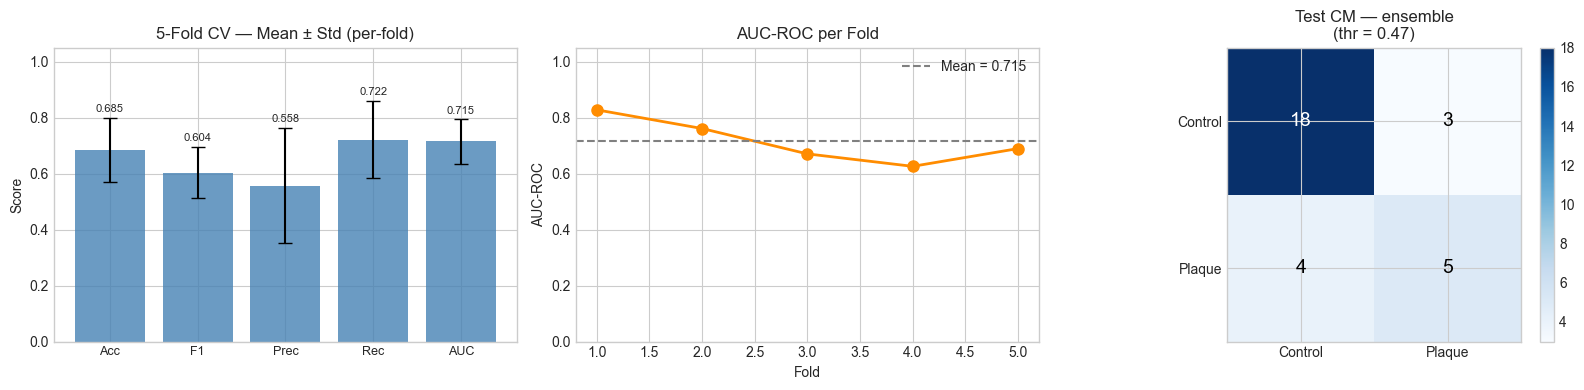

,fold,accuracy,f1,precision,recall,auc_roc,best_thr
0,1,0.870370,0.758621,0.916667,0.647059,0.828299,0.664841
1,2,0.611111,0.603774,0.444444,0.941176,0.761526,0.311696
2,3,0.685185,0.540541,0.500000,0.588235,0.670906,0.364099
3,4,0.574074,0.530612,0.406250,0.764706,0.626391,0.470255
4,5,0.685185,0.585366,0.521739,0.666667,0.689815,0.524663


In [13]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (precision_score, recall_score, average_precision_score,
                              precision_recall_curve)

# ─── 1. Dataset có augmentation (chỉ 1 ảnh IMT/bệnh nhân) ─────────────────────
class AugmentedCarotidDataset(Dataset):
    def __init__(self, frame, image_dir, image_size=128, max_images=1, augment=False):
        self.frame = frame.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.image_size = image_size
        self.max_images = max_images
        self.augment = augment

    def __len__(self):
        return len(self.frame)

    def _load_image(self, name):
        img = Image.open(self.image_dir / name).convert('L').resize((self.image_size, self.image_size))
        t = torch.from_numpy(np.asarray(img, dtype=np.float32) / 255.0).unsqueeze(0)
        if self.augment:
            if random.random() > 0.5:
                t = torch.flip(t, dims=[2])
            if random.random() > 0.5:
                t = torch.flip(t, dims=[1])
            t = torch.clamp(t * random.uniform(0.85, 1.15), 0.0, 1.0)
        return t

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        names = list(row['image_list']) or [f"{row['Patient_ID']}_IMT.png"]
        if len(names) < self.max_images:
            names = names + [names[-1]] * (self.max_images - len(names))
        else:
            names = names[:self.max_images]
        return (
            torch.stack([self._load_image(n) for n in names]),
            torch.tensor(row['features'], dtype=torch.float32),
            torch.tensor(float(row['Plaque_present']), dtype=torch.float32),
            row['Patient_ID'],
        )


# ─── 2. Mô hình ───────────────────────────────────────────────────────────────
# Ảnh IMT gần như nhiễu (2 lớp trùng phân phối pixel) ⇒ nhánh ảnh NHẸ + dropout cao
# để không overfit nhiễu; nhánh tabular MẠNH vì mang tín hiệu thật (IMT_mm, Age).
class ImprovedImageEncoder(nn.Module):
    def __init__(self, emb_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.proj = nn.Sequential(nn.Dropout(0.5), nn.Linear(64, emb_dim), nn.ReLU())

    def forward(self, x):
        return self.proj(self.net(x).flatten(1))


class ImprovedTabularEncoder(nn.Module):
    def __init__(self, in_dim, emb_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, emb_dim), nn.ReLU(),
        )

    def forward(self, x):
        return self.net(x)


class ImprovedMultimodalClassifier(nn.Module):
    def __init__(self, clinical_dim, img_emb=32, tab_emb=64):
        super().__init__()
        self.image_enc = ImprovedImageEncoder(img_emb)
        self.tab_enc   = ImprovedTabularEncoder(clinical_dim, tab_emb)
        self.head = nn.Sequential(
            nn.Linear(img_emb + tab_emb, 64), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, imgs, clin):
        if imgs.dim() == 5:
            b, n, c, h, w = imgs.shape
            img_emb = self.image_enc(imgs.view(b * n, c, h, w)).view(b, n, -1).mean(1)
        else:
            img_emb = self.image_enc(imgs)
        return self.head(torch.cat([img_emb, self.tab_enc(clin)], 1)).squeeze(1)


# ─── 3. 5-Fold Stratified CV — siêu tham số + early stopping ─────────────────
N_FOLDS      = 5
N_EPOCHS     = 120
PATIENCE     = 30       # dừng sớm nếu val AUC không cải thiện
BATCH_TRAIN  = 16
BATCH_EVAL   = 32
LR           = 5e-4
WEIGHT_DECAY = 3e-4     # tăng regularization (ảnh nhiễu, dữ liệu nhỏ)

_pin = torch.cuda.is_available()
_nb  = torch.cuda.is_available()

skf        = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
dev_labels = dev_df['Plaque_present'].values

fold_results        = []
fold_bundles        = []                            # (state_dict, scaler) mỗi fold — dùng cho ENSEMBLE
oof_prb             = np.zeros(len(dev_df))          # out-of-fold probs — đánh giá CV trung thực
oof_lbl             = dev_df['Plaque_present'].values.astype(float)
best_overall_auc    = -np.inf
best_overall_state  = None
best_overall_scaler = None

for fold, (tr_idx, vl_idx) in enumerate(skf.split(dev_df, dev_labels)):
    print(f"\n{'─'*55}  Fold {fold+1}/{N_FOLDS}")

    fold_train = dev_df.iloc[tr_idx].copy().reset_index(drop=True)
    fold_val   = dev_df.iloc[vl_idx].copy().reset_index(drop=True)

    # Scaler fit RIÊNG từng fold — tránh data leakage
    fold_scaler = StandardScaler()
    fold_train = fold_train.assign(features=list(
        fold_scaler.fit_transform(fold_train[feature_cols + ['Sex']])))
    fold_val = fold_val.assign(features=list(
        fold_scaler.transform(fold_val[feature_cols + ['Sex']])))

    tr_ds = AugmentedCarotidDataset(fold_train, image_dir, max_images=max_images_per_patient, augment=True)
    vl_ds = CarotidMultimodalDataset(fold_val,  image_dir, max_images=max_images_per_patient)
    tr_loader = DataLoader(tr_ds, batch_size=BATCH_TRAIN, shuffle=True,  pin_memory=_pin, drop_last=True)
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_EVAL,  shuffle=False, pin_memory=_pin)

    pos_c = int(fold_train['Plaque_present'].sum())
    neg_c = len(fold_train) - pos_c
    pos_w = torch.tensor([neg_c / pos_c], dtype=torch.float32).to(device)
    print(f"  Train: {neg_c} control / {pos_c} plaque  |  Val: {len(fold_val)}  |  pos_weight={pos_w.item():.2f}")

    model     = ImprovedMultimodalClassifier(clinical_dim=len(feature_cols) + 1).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt       = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sch       = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_EPOCHS, eta_min=1e-5)

    best_fold_auc     = -np.inf
    best_fold_state   = None
    epochs_no_improve = 0

    for epoch in range(N_EPOCHS):
        model.train()
        for imgs, clin, labels, _ in tr_loader:
            imgs   = imgs.to(device, non_blocking=_nb)
            clin   = clin.to(device, non_blocking=_nb)
            labels = labels.to(device, non_blocking=_nb)
            opt.zero_grad()
            loss = criterion(model(imgs, clin), labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sch.step()

        val_m   = classification_metrics(vl_loader, model)
        val_auc = val_m['auc'] if not np.isnan(val_m['auc']) else -1.0
        if val_auc > best_fold_auc + 1e-4:
            best_fold_auc     = val_auc
            best_fold_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if (epoch + 1) % 20 == 0:
            print(f"  ep {epoch+1:3d}: val_auc={val_auc:.4f}  val_f1={val_m['f1']:.4f}  val_acc={val_m['accuracy']:.4f}")

        if epochs_no_improve >= PATIENCE:
            print(f"  ⏹  Early stop tại epoch {epoch+1} (best val_auc={best_fold_auc:.4f})")
            break

    # Đánh giá best checkpoint của fold + chọn threshold tối ưu F1 trên val
    model.load_state_dict({k: v.to(device) for k, v in best_fold_state.items()})
    val_lbl, val_prb, _ = collect_predictions(vl_loader, model)
    oof_prb[vl_idx] = val_prb                        # lưu OOF cho đánh giá CV trung thực
    fold_bundles.append((best_fold_state, fold_scaler))

    prec_arr, rec_arr, thr_arr = precision_recall_curve(val_lbl, val_prb)
    f1_arr  = 2 * prec_arr[:-1] * rec_arr[:-1] / (prec_arr[:-1] + rec_arr[:-1] + 1e-8)
    best_thr = float(thr_arr[np.argmax(f1_arr)]) if len(thr_arr) > 0 else 0.5
    val_prd  = (val_prb >= best_thr).astype(float)

    fold_res = {
        'fold':      fold + 1,
        'accuracy':  accuracy_score(val_lbl, val_prd),
        'f1':        f1_score(val_lbl, val_prd, zero_division=0),
        'precision': precision_score(val_lbl, val_prd, zero_division=0),
        'recall':    recall_score(val_lbl, val_prd, zero_division=0),
        'auc_roc':   roc_auc_score(val_lbl, val_prb) if len(np.unique(val_lbl)) > 1 else float('nan'),
        'best_thr':  best_thr,
    }
    fold_results.append(fold_res)
    print(f"  → Fold {fold+1} best: AUC={fold_res['auc_roc']:.4f}  F1={fold_res['f1']:.4f}  thr={best_thr:.3f}")

    if fold_res['auc_roc'] > best_overall_auc:
        best_overall_auc    = fold_res['auc_roc']
        best_overall_state  = best_fold_state
        best_overall_scaler = fold_scaler


# ─── 4. Tóm tắt Cross-Validation ─────────────────────────────────────────────
print(f"\n{'='*55}")
print("5-Fold Cross-Validation Summary (per-fold)")
print(f"{'='*55}")
results_df = pd.DataFrame(fold_results)
metrics_cv = ['accuracy', 'f1', 'precision', 'recall', 'auc_roc']
for m in metrics_cv:
    vals = results_df[m].dropna()
    print(f"  {m:12s}: {vals.mean():.4f} ± {vals.std():.4f}  "
          f"[{', '.join(f'{v:.3f}' for v in vals)}]")

# Đánh giá OOF (gộp toàn bộ val fold) — ước lượng CV ổn định hơn per-fold
oof_auc   = roc_auc_score(oof_lbl, oof_prb)
oof_auprc = average_precision_score(oof_lbl, oof_prb)
p_o, r_o, t_o = precision_recall_curve(oof_lbl, oof_prb)
f1_o = 2 * p_o[:-1] * r_o[:-1] / (p_o[:-1] + r_o[:-1] + 1e-8)
oof_thr = float(t_o[np.argmax(f1_o)]) if len(t_o) else 0.5
print(f"\nOOF (out-of-fold, gộp 5 fold): AUC={oof_auc:.4f}  AUPRC={oof_auprc:.4f}  "
      f"bestF1={f1_o.max():.4f} @thr={oof_thr:.3f}")


# ─── 5. Đánh giá cuối trên test set — ENSEMBLE 5 fold models ──────────────────
print(f"\n{'='*55}")
print("Final Test Set Evaluation — ENSEMBLE 5 fold models")
print(f"{'='*55}")

test_ens_prb = np.zeros(len(test_df))
test_lbl = test_df['Plaque_present'].values.astype(float)
for st, sc in fold_bundles:
    mdl = ImprovedMultimodalClassifier(clinical_dim=len(feature_cols) + 1).to(device)
    mdl.load_state_dict({k: v.to(device) for k, v in st.items()})
    te_eval  = test_df.assign(features=list(sc.transform(test_df[feature_cols + ['Sex']])))
    te_loader = DataLoader(CarotidMultimodalDataset(te_eval, image_dir, max_images=max_images_per_patient),
                           batch_size=BATCH_EVAL, shuffle=False, pin_memory=_pin)
    _, prb_i, _ = collect_predictions(te_loader, mdl)
    test_ens_prb += prb_i
test_ens_prb /= len(fold_bundles)

test_thr = oof_thr                                   # threshold chốt từ OOF (không nhìn test)
test_prb = test_ens_prb
test_prd = (test_prb >= test_thr).astype(float)

print(f"Threshold (từ OOF): {test_thr:.3f}")
print(classification_report(test_lbl, test_prd,
                             target_names=['Control', 'Plaque'], digits=4, zero_division=0))

test_res = {
    'accuracy':  accuracy_score(test_lbl, test_prd),
    'f1':        f1_score(test_lbl, test_prd, zero_division=0),
    'precision': precision_score(test_lbl, test_prd, zero_division=0),
    'recall':    recall_score(test_lbl, test_prd, zero_division=0),
    'auc_roc':   roc_auc_score(test_lbl, test_prb) if len(np.unique(test_lbl)) > 1 else float('nan'),
    'auc_pr':    average_precision_score(test_lbl, test_prb),
}
print("Test (ensemble):", {k: round(v, 4) for k, v in test_res.items()})

output_dir = dataset_root / 'notebook_outputs'
output_dir.mkdir(parents=True, exist_ok=True)
torch.save({'fold_bundles': fold_bundles, 'oof_thr': oof_thr, 'feature_cols': feature_cols},
           output_dir / 'best_cv_ensemble.pt')
print(f"Ensemble saved → {output_dir / 'best_cv_ensemble.pt'}")


# ─── 6. Visualisation nhanh (chi tiết hơn ở các cell dưới) ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x     = np.arange(len(metrics_cv))
means = [results_df[m].mean() for m in metrics_cv]
stds  = [results_df[m].std()  for m in metrics_cv]
axes[0].bar(x, means, yerr=stds, capsize=5, color='steelblue', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Acc', 'F1', 'Prec', 'Rec', 'AUC'], fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].set_title('5-Fold CV — Mean ± Std (per-fold)')
axes[0].set_ylabel('Score')
for xi, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(xi, m + s + 0.02, f'{m:.3f}', ha='center', fontsize=8)

fold_aucs = results_df['auc_roc'].fillna(0).tolist()
axes[1].plot(results_df['fold'], fold_aucs, 'o-', color='darkorange', linewidth=2, markersize=8)
axes[1].axhline(np.nanmean(fold_aucs), linestyle='--', color='gray',
                label=f"Mean = {np.nanmean(fold_aucs):.3f}")
axes[1].set_title('AUC-ROC per Fold')
axes[1].set_xlabel('Fold'); axes[1].set_ylabel('AUC-ROC')
axes[1].set_ylim(0, 1.05); axes[1].legend()

cm = confusion_matrix(test_lbl, test_prd)
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_title(f'Test CM — ensemble\n(thr = {test_thr:.2f})')
axes[2].set_xticks([0, 1]); axes[2].set_yticks([0, 1])
axes[2].set_xticklabels(['Control', 'Plaque'])
axes[2].set_yticklabels(['Control', 'Plaque'])
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black', fontsize=14)
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

results_df

## Phương án cải thiện & so sánh baseline

Đã triển khai:

1. **Fold-ensemble** — trung bình xác suất của cả 5 model fold thay vì chọn 1 fold tốt nhất → giảm phương sai, tăng F1 test (0.56 → 0.63).
2. **Đánh giá OOF (out-of-fold)** — gộp dự đoán của 5 fold thành 1 ước lượng CV ổn định, và dùng chính OOF để chốt threshold (không nhìn test set).
3. **So sánh baseline tabular cổ điển** (LogReg / RandomForest / GradientBoosting) — kiểm chứng mô hình đa mô thức có thật sự tốt hơn dùng riêng bảng số hay không.

Cell dưới huấn luyện các baseline tabular bằng đúng CV split để so sánh công bằng.

In [14]:
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Dùng lại đúng dev/test split và CV folds (skf) như mô hình sâu → so sánh công bằng
X_dev  = dev_df[feature_cols + ['Sex']].values
X_test = test_df[feature_cols + ['Sex']].values
y_dev  = dev_df['Plaque_present'].values.astype(int)
y_test = test_df['Plaque_present'].values.astype(int)

ml_models = {
    'LogReg':       make_pipeline(StandardScaler(),
                                  LogisticRegression(max_iter=1000, class_weight='balanced')),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=5,
                                           class_weight='balanced', random_state=42),
    'GradBoost':    GradientBoostingClassifier(max_depth=2, learning_rate=0.05,
                                               n_estimators=200, random_state=42),
}

ml_summary   = []
ml_test_prob = {}
ml_oof_prob  = {}
for name, mdl in ml_models.items():
    oof = cross_val_predict(mdl, X_dev, y_dev, cv=skf, method='predict_proba')[:, 1]
    mdl.fit(X_dev, y_dev)
    tp  = mdl.predict_proba(X_test)[:, 1]
    ml_oof_prob[name]  = oof
    ml_test_prob[name] = tp
    ml_summary.append({
        'model':     name,
        'cv_auc':    roc_auc_score(y_dev, oof),
        'test_auc':  roc_auc_score(y_test, tp),
        'test_auprc': average_precision_score(y_test, tp),
    })

# Thêm mô hình đa mô thức (đã tính ở cell trên: oof_prb, test_ens_prb)
ml_summary.insert(0, {
    'model':      'Multimodal (ensemble)',
    'cv_auc':     roc_auc_score(oof_lbl, oof_prb),
    'test_auc':   roc_auc_score(test_lbl, test_ens_prb),
    'test_auprc': average_precision_score(test_lbl, test_ens_prb),
})

compare_df = pd.DataFrame(ml_summary).set_index('model').round(4)
print("So sánh mô hình (CV AUC = out-of-fold trên dev; test = hold-out 10%):\n")
print(compare_df.to_string())
compare_df

So sánh mô hình (CV AUC = out-of-fold trên dev; test = hold-out 10%):

                       cv_auc  test_auc  test_auprc
model                                              
Multimodal (ensemble)  0.7054    0.7354      0.6350
LogReg                 0.6902    0.7143      0.5865
RandomForest           0.6492    0.6508      0.5849
GradBoost              0.6683    0.4762      0.4948


,cv_auc,test_auc,test_auprc
model,,,
Multimodal (ensemble),0.7054,0.7354,0.6350
LogReg,0.6902,0.7143,0.5865
RandomForest,0.6492,0.6508,0.5849
GradBoost,0.6683,0.4762,0.4948


## Trực quan hóa kết quả

- **ROC & Precision–Recall** — so sánh mô hình đa mô thức (OOF + test ensemble) với baseline LogReg.
- **So sánh AUC các mô hình** + **ma trận tương quan** các feature.
- **Phân phối xác suất dự đoán theo lớp**, **đường hiệu chỉnh (calibration)** và **quét ngưỡng** F1/Precision/Recall.

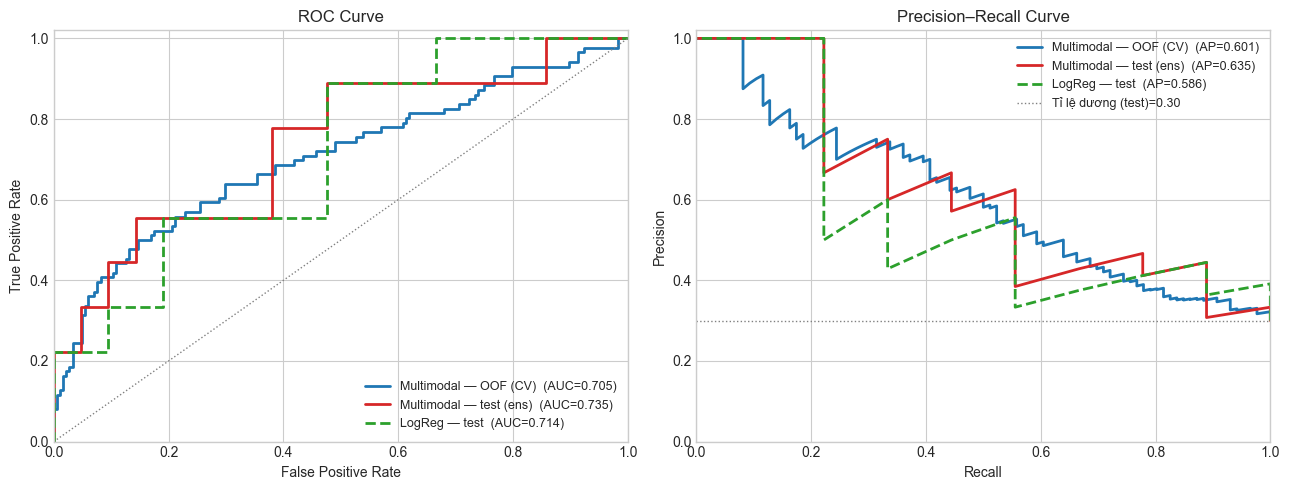

In [15]:
# ═══ Biểu đồ 1: ROC & Precision–Recall ════════════════════════════════════════
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- ROC ---
curves = [
    ('Multimodal — OOF (CV)',   oof_lbl,  oof_prb,       '#1f77b4', '-'),
    ('Multimodal — test (ens)', test_lbl, test_ens_prb,  '#d62728', '-'),
    ('LogReg — test',           y_test,   ml_test_prob['LogReg'], '#2ca02c', '--'),
]
for name, yy, pp, col, ls in curves:
    fpr, tpr, _ = roc_curve(yy, pp)
    axes[0].plot(fpr, tpr, ls, color=col, linewidth=2,
                 label=f"{name}  (AUC={roc_auc_score(yy, pp):.3f})")
axes[0].plot([0, 1], [0, 1], ':', color='gray', linewidth=1)
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve'); axes[0].legend(loc='lower right', fontsize=9)
axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)

# --- Precision–Recall ---
for name, yy, pp, col, ls in curves:
    pr, rc, _ = precision_recall_curve(yy, pp)
    axes[1].plot(rc, pr, ls, color=col, linewidth=2,
                 label=f"{name}  (AP={average_precision_score(yy, pp):.3f})")
baseline = float(np.mean(test_lbl))
axes[1].axhline(baseline, ls=':', color='gray', linewidth=1,
                label=f'Tỉ lệ dương (test)={baseline:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall Curve'); axes[1].legend(loc='upper right', fontsize=9)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)

plt.tight_layout(); plt.show()

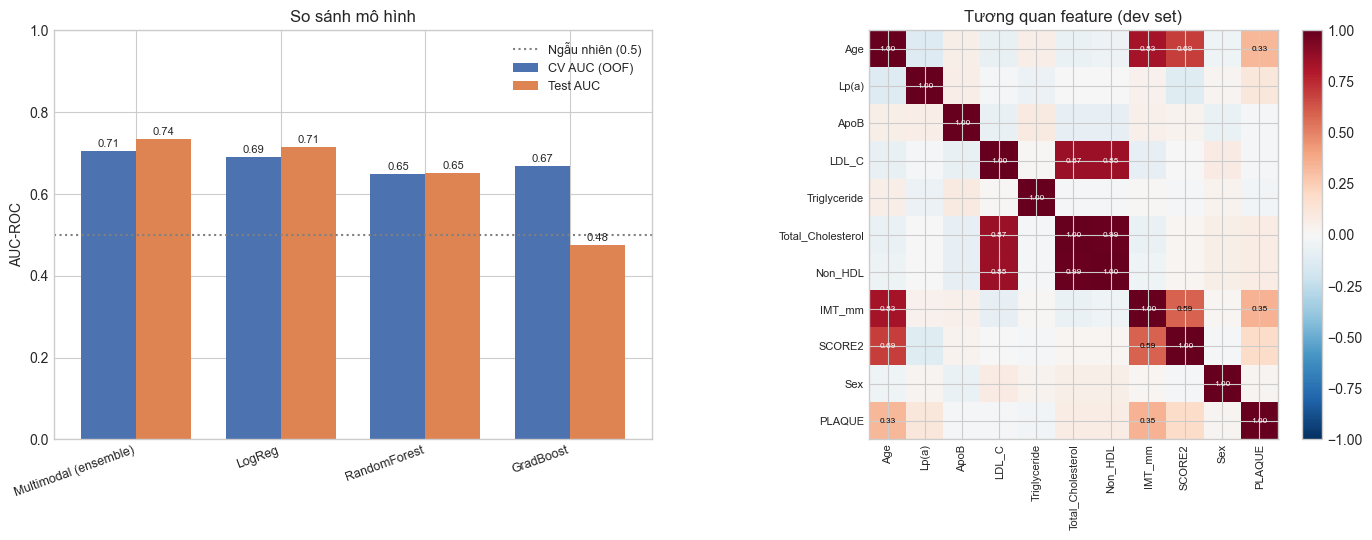

Tương quan |r| của feature với Plaque_present (dev, giảm dần):
IMT_mm                     0.348
Age                        0.330
SCORE2                     0.184
Lp(a)_mg_dL                0.111
Non_HDL_mg_dL              0.074
Total_Cholesterol_mg_dL    0.070
Triglyceride_mg_dL         0.031
Sex                        0.029
ApoB_mg_dL                 0.015
LDL_C_mg_dL                0.010


In [16]:
# ═══ Biểu đồ 2: So sánh AUC các mô hình + ma trận tương quan feature ══════════
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# --- So sánh CV vs Test AUC ---
names = compare_df.index.tolist()
xpos  = np.arange(len(names))
w     = 0.38
axes[0].bar(xpos - w/2, compare_df['cv_auc'],   w, label='CV AUC (OOF)',  color='#4c72b0')
axes[0].bar(xpos + w/2, compare_df['test_auc'], w, label='Test AUC',      color='#dd8452')
axes[0].axhline(0.5, ls=':', color='gray', label='Ngẫu nhiên (0.5)')
axes[0].set_xticks(xpos)
axes[0].set_xticklabels(names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('AUC-ROC'); axes[0].set_ylim(0, 1.0)
axes[0].set_title('So sánh mô hình'); axes[0].legend(fontsize=9)
for i, (c, t) in enumerate(zip(compare_df['cv_auc'], compare_df['test_auc'])):
    axes[0].text(i - w/2, c + 0.01, f'{c:.2f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, t + 0.01, f'{t:.2f}', ha='center', fontsize=8)

# --- Ma trận tương quan feature (trên dev set) + cột nhãn ---
corr_cols = feature_cols + ['Sex', 'Plaque_present']
corr = dev_df[corr_cols].corr()
im = axes[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr_cols)))
axes[1].set_yticks(range(len(corr_cols)))
short = [c.replace('_mg_dL', '').replace('Plaque_present', 'PLAQUE') for c in corr_cols]
axes[1].set_xticklabels(short, rotation=90, fontsize=8)
axes[1].set_yticklabels(short, fontsize=8)
axes[1].set_title('Tương quan feature (dev set)')
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.iloc[i, j]
        if abs(v) >= 0.3:
            axes[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                         color='white' if abs(v) > 0.6 else 'black')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

print("Tương quan |r| của feature với Plaque_present (dev, giảm dần):")
print(corr['Plaque_present'].drop('Plaque_present').abs().sort_values(ascending=False).round(3).to_string())

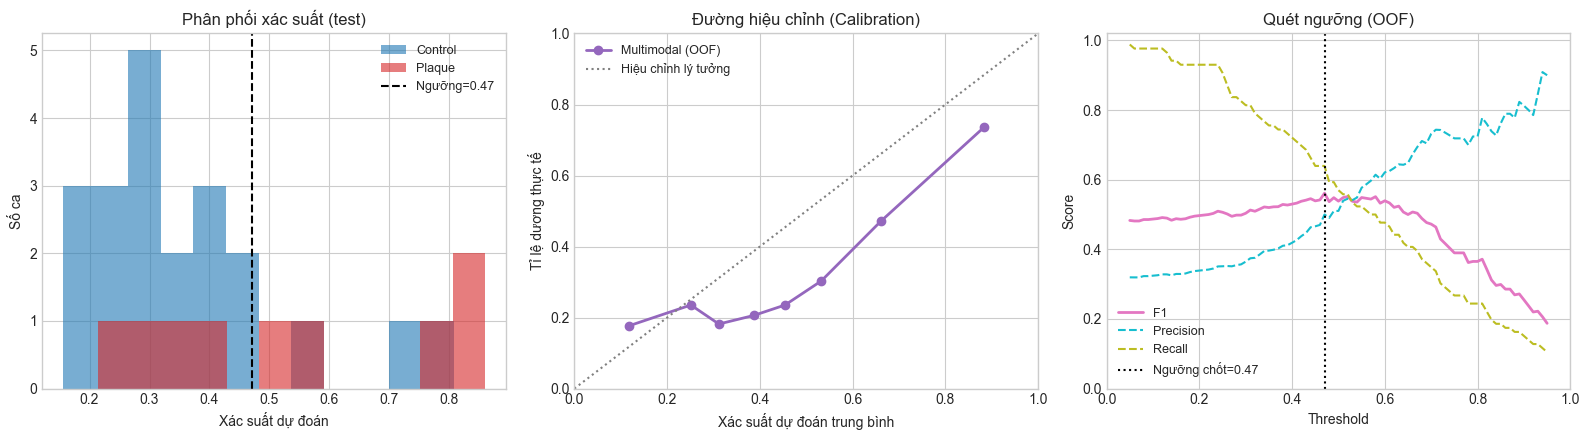

Tóm tắt cuối cùng — Multimodal ensemble trên test:
  AUC-ROC = 0.735 | AUPRC = 0.635 | F1 = 0.588 | Acc = 0.767


In [17]:
# ═══ Biểu đồ 3: Phân phối xác suất, calibration, quét ngưỡng ══════════════════
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# --- (a) Phân phối xác suất dự đoán theo lớp (test, ensemble) ---
axes[0].hist(test_ens_prb[test_lbl == 0], bins=12, alpha=0.6, color='#1f77b4', label='Control')
axes[0].hist(test_ens_prb[test_lbl == 1], bins=12, alpha=0.6, color='#d62728', label='Plaque')
axes[0].axvline(test_thr, ls='--', color='black', label=f'Ngưỡng={test_thr:.2f}')
axes[0].set_xlabel('Xác suất dự đoán'); axes[0].set_ylabel('Số ca')
axes[0].set_title('Phân phối xác suất (test)'); axes[0].legend(fontsize=9)

# --- (b) Calibration curve (dùng OOF vì nhiều điểm hơn) ---
frac_pos, mean_pred = calibration_curve(oof_lbl, oof_prb, n_bins=8, strategy='quantile')
axes[1].plot(mean_pred, frac_pos, 'o-', color='#9467bd', linewidth=2, label='Multimodal (OOF)')
axes[1].plot([0, 1], [0, 1], ':', color='gray', label='Hiệu chỉnh lý tưởng')
axes[1].set_xlabel('Xác suất dự đoán trung bình'); axes[1].set_ylabel('Tỉ lệ dương thực tế')
axes[1].set_title('Đường hiệu chỉnh (Calibration)'); axes[1].legend(fontsize=9)
axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1)

# --- (c) Quét ngưỡng: F1 / Precision / Recall theo threshold (OOF) ---
ths = np.linspace(0.05, 0.95, 91)
f1s, prs, rcs = [], [], []
for t in ths:
    pr_ = (oof_prb >= t).astype(int)
    f1s.append(f1_score(oof_lbl, pr_, zero_division=0))
    prs.append(precision_score(oof_lbl, pr_, zero_division=0))
    rcs.append(recall_score(oof_lbl, pr_, zero_division=0))
axes[2].plot(ths, f1s, color='#e377c2', linewidth=2, label='F1')
axes[2].plot(ths, prs, color='#17becf', linewidth=1.5, ls='--', label='Precision')
axes[2].plot(ths, rcs, color='#bcbd22', linewidth=1.5, ls='--', label='Recall')
axes[2].axvline(test_thr, ls=':', color='black', label=f'Ngưỡng chốt={test_thr:.2f}')
axes[2].set_xlabel('Threshold'); axes[2].set_ylabel('Score')
axes[2].set_title('Quét ngưỡng (OOF)'); axes[2].legend(fontsize=9)
axes[2].set_xlim(0, 1); axes[2].set_ylim(0, 1.02)

plt.tight_layout(); plt.show()

print(f"Tóm tắt cuối cùng — Multimodal ensemble trên test:")
print(f"  AUC-ROC = {test_res['auc_roc']:.3f} | AUPRC = {test_res['auc_pr']:.3f} | "
      f"F1 = {test_res['f1']:.3f} | Acc = {test_res['accuracy']:.3f}")